In [1]:
import os
from pathlib import Path
from matplotlib import rc
from matplotlib import font_manager
import matplotlib.pyplot as plt
from prf_expect.utils import io
from prf_expect.utils.viz import desaturate_palette, sample_cmap, cm_to_inch

subjects = ["sub-001", "sub-002", "sub-004", "sub-005", "sub-007", "sub-009", "sub-012"]
conditions = ["violation", "omission", "sparse",]
space = "fsaverage"
settings = io.load_settings()
data_dir = Path(settings['general']['data_dir'], "data")
base_dir = data_dir / "derivatives" / "prf_data"

# Build paths for all subjects x conditions
rsq_paths = {}
for sub in subjects:
    rsq_paths[sub] = {}
    for cond in conditions:
        fn = f"{sub}_ses-1_task-{cond}_runs-all_space-{space}_gridrsqs.npy"
        rsq_paths[sub][cond] = os.path.join(
            base_dir, sub, "ses-1", "prf_fits", "prf_predictions", fn
        )

Loading settings from /Users/dionysus/Library/CloudStorage/OneDrive-Personal/Workbench/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml


In [2]:
base_dir

PosixPath('/Users/dionysus/Downloads/data/derivatives/prf_data')

In [3]:
cwd = os.getcwd()
figure_result_dir = Path(cwd).parent / "figures"

In [4]:
import numpy as np

# Load available data
rsqs_all = {}  # {sub: {cond: array}}
for sub in subjects:
    rsqs_all[sub] = {}
    for cond in conditions:
        path = rsq_paths[sub][cond]
        if os.path.exists(path):
            rsqs_all[sub][cond] = np.load(path)
            print(f"{sub} {cond}: {rsqs_all[sub][cond].shape}")
        else:
            print(f"{sub} {cond}: NOT FOUND")

sub-001 violation: (370, 200)
sub-001 omission: (370, 200)
sub-001 sparse: (370, 200)
sub-002 violation: (370, 200)
sub-002 omission: (370, 200)
sub-002 sparse: (370, 200)
sub-004 violation: (370, 200)
sub-004 omission: (370, 200)
sub-004 sparse: (370, 200)
sub-005 violation: (370, 200)
sub-005 omission: (370, 200)
sub-005 sparse: (370, 200)
sub-007 violation: (370, 200)
sub-007 omission: (370, 200)
sub-007 sparse: (370, 200)
sub-009 violation: (370, 200)
sub-009 omission: (370, 200)
sub-009 sparse: (370, 200)
sub-012 violation: (370, 200)
sub-012 omission: (370, 200)
sub-012 sparse: (370, 200)


In [5]:
cwd = os.getcwd()
font_dirs = [Path(cwd).parent.parent.parent / "arial"]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

rc("pdf", fonttype=42, use14corefonts=False)
rc("axes", linewidth=0.5)
rc("font", **{"family": "Arial"})
rc("text", usetex=False)
rc("xtick", labelsize=6)
rc("ytick", labelsize=6)
rc("axes", labelsize=7)
rc("legend", fontsize=6)

plt.rcParams["xtick.major.width"] = 0.5
plt.rcParams["ytick.major.width"] = 0.5
plt.rcParams["xtick.major.size"] = 2
plt.rcParams["ytick.major.size"] = 2
plt.rcParams["xtick.minor.width"] = 0.5
plt.rcParams["ytick.minor.width"] = 0.5
plt.rcParams["xtick.minor.size"] = 1
plt.rcParams["ytick.minor.size"] = 1

# set up figure parameters
markeredgecolor = ".4"
bar_linewidth = 0.5
bar_alpha = 0.7
xticks_rotation = 45
marker = "s"
marker_edge_width = 0.5
markersize = 3 / 2.54
errorbar_linewidth = 0.5
errorbar_capsize = 2 / 2.54
errorbar_capthick = 0.5

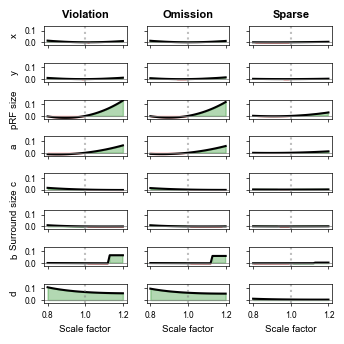

In [6]:
from scipy.stats import wilcoxon

# Order used when grid R² arrays were generated
all_param_cols = ["x", "y", "prf_size", "prf_ampl", "bold_bsl", "surr_ampl", "surr_size", "neur_bsl", "surr_bsl"]
# Parameters to show in the figure
plot_param_cols = [p for p in all_param_cols if p != "bold_bsl"]

# DN model parameter labels for display
param_label_map = {
    "x": "x",
    "y": "y",
    "prf_size": "pRF size",
    "prf_ampl": "a",
    "surr_ampl": "c",
    "surr_size": "Surround size",
    "neur_bsl": "b",
    "surr_bsl": "d",
}

scale_factors = np.arange(0.80, 1.20 + 1e-9, 0.01)
scale_factors = np.sort(np.unique(np.append(scale_factors, 1.0)))
non_baseline = scale_factors[scale_factors != 1.0]
n_per_param = len(non_baseline)
n_params = len(plot_param_cols)
n_conds = len(conditions)

# Map each parameter to its block index in rsqs (keeps indexing correct when plotting a subset)
param_to_block_idx = {p: i for i, p in enumerate(all_param_cols)}

# --- ΔR² plot (original - simulated), averaged across subjects ---
fig1, axes1 = plt.subplots(n_params, n_conds, figsize=cm_to_inch(9, 9),
                            sharex=True, sharey=True, squeeze=False)

for col, cond in enumerate(conditions):
    for row, param_name in enumerate(plot_param_cols):
        ax1 = axes1[row, col]

        # Pool ΔR² across subjects for each scale factor
        delta_rsqs = []
        block_idx = param_to_block_idx[param_name]
        for sub in subjects:
            if cond not in rsqs_all.get(sub, {}):
                continue
            rsqs = rsqs_all[sub][cond]
            original_rsq = rsqs[0]

            start = 1 + block_idx * n_per_param
            end = start + n_per_param
            sim_rsqs = rsqs[start:end]
            delta = original_rsq[None, :] - sim_rsqs
            delta_rsqs.append(delta)

        if not delta_rsqs:
            continue

        delta_all = np.concatenate(delta_rsqs, axis=1)
        mean_delta = np.mean(delta_all, axis=1)

        ax1.plot(non_baseline, mean_delta, "-", color="k")
        ax1.fill_between(non_baseline, 0, mean_delta,
                    where=mean_delta > 0, color="green", alpha=0.3)
        ax1.fill_between(non_baseline, 0, mean_delta,
                    where=mean_delta < 0, color="red", alpha=0.3)
        ax1.axhline(0, color="gray", ls="-", lw=0.5)
        ax1.axvline(1.0, color="gray", ls=":", alpha=0.5)

        if row == 0:
            ax1.set_title(str.capitalize(cond), fontweight="bold", fontsize=8)
        if col == 0:
            ax1.set_ylabel(param_label_map.get(param_name, param_name))
        if row == n_params - 1:
            ax1.set_xlabel("Scale factor")

# fig1.suptitle("Mean ΔR² (original − simulated), pooled across subjects\n"
#             "Green = original better, Red = simulated better",
#             fontweight="bold")
fig1.tight_layout()

plt.show()
fig1.savefig(figure_result_dir / f"group_analysis-pRF_space-fsaverage_desc-prf_viz_grid_simulation_deltarsq.pdf", dpi=600, bbox_inches='tight')
fig1.savefig(figure_result_dir / f"group_analysis-pRF_space-fsaverage_desc-prf_viz_grid_simulation_deltarsq.png", dpi=600, bbox_inches='tight')

In [7]:
# Import the necessary packages
import itertools
import numpy as np
import sys
import glob
import os
import time
from time import strftime, localtime
import pandas as pd
import cortex as cx
from prf_expect.utils import io
from prf_expect.utils.fit import PRFModel


def load_psc_pe_data(subject, space, run, psc_dir, base_name):
    data = np.concatenate(
        [
            np.load(file).T
            for LR in ["L", "R"]
            for file in sorted(
                glob.glob(
                    os.path.join(
                        psc_dir,
                        f"{subject}_ses-1_task-PE_{run}_space-{space}_hemi-{LR}_desc-denoised_bold_psc_{base_name}.npy",
                    )
                )
            )
        ]
    )
    return data


# calculate R^2 for each condition
def calculate_rsq(data, pred):
    ss_res = np.sum((data - pred) ** 2, axis=1)
    ss_tot = np.sum((data - np.mean(data, axis=1, keepdims=True)) ** 2, axis=1)
    rsq = 1 - (ss_res / ss_tot)
    return rsq


def build_prf_param_grid(
    prf_params: pd.DataFrame,
    scale_min: float = -0.20,
    scale_max: float = 0.20,
    step: float = 0.01,
):
    """Return parameter columns and a grid that scales one parameter at a time.

    Instead of the full Cartesian product, we vary each parameter independently
    across the scale factors while keeping others at 1.0. A baseline (all ones)
    is included as the first row.
    """

    param_cols = [
        col
        for col in [
            "x",
            "y",
            "prf_size",
            "prf_ampl",
            "bold_bsl",
            "surr_ampl",
            "surr_size",
            "neur_bsl",
            "surr_bsl",
        ]
        if col in prf_params.columns
    ]

    if not param_cols:
        raise ValueError("No parameter columns found to scale")

    scale_factors = np.arange(1 + scale_min, 1 + scale_max + 1e-9, step)
    if 1.0 not in scale_factors:
        scale_factors = np.sort(np.unique(np.append(scale_factors, 1.0)))

    # Build grid: baseline (all ones) plus per-parameter scaling vectors
    grid = [np.ones(len(param_cols))]
    for idx, _ in enumerate(param_cols):
        for sf in scale_factors:
            if sf == 1.0:
                continue
            vec = np.ones(len(param_cols))
            vec[idx] = sf
            grid.append(vec)

    factor_grid = np.array(grid)

    return param_cols, factor_grid


# Import settings data from json file

settings = io.load_settings()

# Define paths and data exp parameters
data_dir = os.path.join(settings["general"]["data_dir"], "data")
tasks = settings["design"]["tasks"]
space = settings["mri"]["space"]
PE_runs = settings["design"]["runs_per_task"]
roi_verts = cx.get_roi_verts('fsaverage', ('V1',))
roi_indices = roi_verts["V1"]
nr_best_voxels = 200
surprise_ratio_all_subs = []
rsq_all_subs = []
# Loop over all subjects of interest to make the predictions for
for subject in subjects:
    start_time = time.time()
    print(
        f"Starting to predict timecourses for subject: {subject} at {strftime('%Y-%m-%d %H:%M:%S', localtime(start_time))}",
        flush=True,
    )

    sub_dir = os.path.join(data_dir, "derivatives", "prf_data", subject, "ses-1")
    prf_fits_dir = os.path.join(sub_dir, "prf_fits")
    prf_params_dir = os.path.join(prf_fits_dir, "prf_params")
    dm_dir = os.path.join(sub_dir, "dms")
    psc_dir = os.path.join(sub_dir, "cut_and_averaged")

    # make output directory to store the predictions in
    output_dir = os.path.join(prf_fits_dir, "prf_predictions")
    os.makedirs(output_dir, exist_ok=True)

    # load in the model parameters from a pickle file
    params_tsv_name = os.path.join(
        prf_params_dir,
        f"{subject}_ses-1_final-fit_space-{space}_model-norm_stage-iter_desc-prf_params.tsv",
    )
    prf_params = pd.read_csv(params_tsv_name, sep="\t")

    # perform mask to only keep the best voxels in V1
    prf_params = prf_params.iloc[roi_indices]
    prf_params = prf_params.sort_values(by="r2", ascending=False).head(nr_best_voxels)
    rsq = prf_params["r2"].values
    rsq_all_subs.append(rsq)
    # get the index of the best voxels in the original data
    best_voxel_indices = prf_params.index.values
    prf_params = prf_params.reset_index(drop=True)

    # Concatenate all runs per condition before predicting
    omission_data_runs = []
    sparse_data_runs = []
    violation_data_runs = []
    omission_dm_runs = []
    sparse_dm_runs = []
    violation_dm_runs = []

    for run in PE_runs:
        omission_data_runs.append(
            load_psc_pe_data(subject, space, run, psc_dir, "omission")[best_voxel_indices]
        )
        sparse_data_runs.append(
            load_psc_pe_data(subject, space, run, psc_dir, "sparse")[best_voxel_indices]
        )
        violation_data_runs.append(
            load_psc_pe_data(subject, space, run, psc_dir, "violation")[best_voxel_indices]
        )

        omission_dm_runs.append(
            np.load(os.path.join(dm_dir, f"{subject}_ses-1_task-omission_{run}_dm.npy"))
        )
        sparse_dm_runs.append(
            np.load(os.path.join(dm_dir, f"{subject}_ses-1_task-sparse_{run}_dm.npy"))
        )
        violation_dm_runs.append(
            np.load(os.path.join(dm_dir, f"{subject}_ses-1_task-violation_{run}_dm.npy"))
        )

    # Concatenate along time axis (axis=1 for data, axis=-1 for dms)
    omission_data = np.concatenate(omission_data_runs, axis=1)
    sparse_data = np.concatenate(sparse_data_runs, axis=1)
    violation_data = np.concatenate(violation_data_runs, axis=1)

    omission_dm = np.concatenate(omission_dm_runs, axis=-1)
    sparse_dm = np.concatenate(sparse_dm_runs, axis=-1)
    violation_dm = np.concatenate(violation_dm_runs, axis=-1)

    # Predict once on concatenated data
    omission_fn = f"{subject}_ses-1_task-omission_runs-all_space-{space}_gridrsqs.npy"
    sparse_fn = f"{subject}_ses-1_task-sparse_runs-all_space-{space}_gridrsqs.npy"
    violation_fn = f"{subject}_ses-1_task-violation_runs-all_space-{space}_gridrsqs.npy"

    base_params = prf_params.to_numpy()
    r2_vals = prf_params["r2"].values if "r2" in prf_params.columns else None

    n_vox = base_params.shape[0]

    # Initialize PRF models once per condition to avoid repeated setup
    prf_obj_omit = PRFModel()
    prf_obj_omit.get_dm(omission_dm)
    prf_obj_omit.get_data(omission_data)

    prf_obj_spar = PRFModel()
    prf_obj_spar.get_dm(sparse_dm)
    prf_obj_spar.get_data(sparse_data)

    prf_obj_viol = PRFModel()
    prf_obj_viol.get_dm(violation_dm)
    prf_obj_viol.get_data(violation_data)

    prf_params_small = prf_params.copy()
    prf_params_small["prf_size"] = prf_params_small["prf_size"] * 0.9

    prf_obj_omit.load_params(prf_params_small, model="norm", stage="iter")
    prf_preds_omit = prf_obj_omit.make_predictions(model="norm")

    prf_obj_spar.load_params(prf_params, model="norm", stage="iter")
    prf_preds_spar = prf_obj_spar.make_predictions(model="norm")

    prf_obj_viol.load_params(prf_params_small, model="norm", stage="iter")
    prf_preds_viol = prf_obj_viol.make_predictions(model="norm")

    # Calculate surprise ratio per voxel
    betas_omit = np.full(n_vox, np.nan)
    betas_spar = np.full(n_vox, np.nan)
    surprise_ratio = np.full(n_vox, np.nan)

    for vertex in range(n_vox):
        if (
            np.isnan(prf_preds_omit[vertex]).any()
            or np.isnan(prf_preds_spar[vertex]).any()
            or np.isnan(violation_data[vertex]).any()
        ):
            continue

        x1 = np.vstack([prf_preds_omit[vertex], prf_preds_spar[vertex]]).T
        y = violation_data[vertex]

        betas1, _, _, _ = np.linalg.lstsq(x1, y, rcond=None)
        betas_omit[vertex] = betas1[0]
        betas_spar[vertex] = betas1[1]

        denom = betas1[0] + betas1[1]
        if denom != 0:
            surprise_ratio[vertex] = (betas1[1] / denom) - 0.5
        else:
            surprise_ratio[vertex] = 0
    
    surprise_ratio_all_subs.append(surprise_ratio)

    print(f"{subject}: mean surprise ratio = {np.nanmean(surprise_ratio):.4f}, "
          f"median = {np.nanmedian(surprise_ratio):.4f}, "
          f"valid voxels = {np.sum(~np.isnan(surprise_ratio))}/{n_vox}")

    end_time = time.time()
    print(
        f"Finished fitting for {subject} at {strftime('%Y-%m-%d %H:%M:%S', localtime(end_time))}",
        flush=True,
    )
    print(
        f"Total time fitting for {subject} was {(end_time - start_time)/60/60:.2f} hours",
        flush=True,
    )
    print("===================================", flush=True)

Loading settings from /Users/dionysus/Library/CloudStorage/OneDrive-Personal/Workbench/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml
Starting to predict timecourses for subject: sub-001 at 2026-03-24 00:21:41
Loading settings from /Users/dionysus/Library/CloudStorage/OneDrive-Personal/Workbench/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml
Loading settings from /Users/dionysus/Library/CloudStorage/OneDrive-Personal/Workbench/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml
Loading settings from /Users/dionysus/Library/CloudStorage/OneDrive-Personal/Workbench/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml
Inserting parameters from <class 'pandas.core.frame.DataFrame'> as 'norm_iter' in <prf_expect.utils.fit.PRFModel object at 0x16cbf3770>
Inserting parameters from <class 'pandas.core.frame.DataFrame'> as 'norm_iter' in <prf_expect.utils.fit.PRFModel object at 0x16cbff750>
Inserting parameters from <class 'pandas.core.frame.DataFrame'> as '

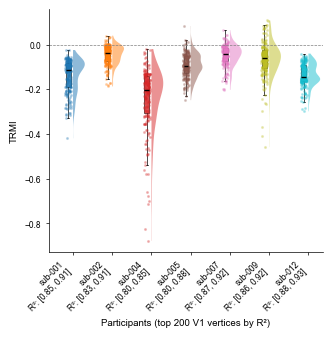

In [8]:
# plot the distribution of surprise ratios for all subjects in one figure
fig, ax = plt.subplots(figsize=cm_to_inch(9, 8))

n_subs = len(subjects)
positions = np.arange(n_subs)
sub_colors = sample_cmap('tab10', n_subs)

for i, (sub, sr) in enumerate(zip(subjects, surprise_ratio_all_subs)):
    valid = sr[~np.isnan(sr)]
    pos = positions[i]

    # Half-violin (right side only)
    parts = ax.violinplot(valid, positions=[pos], showextrema=False, widths=0.6)
    for pc in parts['bodies']:
        m = np.mean(pc.get_paths()[0].vertices[:, 0])
        pc.get_paths()[0].vertices[:, 0] = np.clip(
            pc.get_paths()[0].vertices[:, 0], m, np.inf)
        pc.set_facecolor(sub_colors[i])
        pc.set_edgecolor('none')
        pc.set_alpha(0.5)

    # Box plot (narrow, left side)
    bp = ax.boxplot(valid, positions=[pos - 0.12], widths=0.12,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='k', linewidth=1),
                    whiskerprops=dict(linewidth=0.5),
                    capprops=dict(linewidth=0.5),
                    boxprops=dict(facecolor=sub_colors[i], edgecolor='k',
                                linewidth=0.5, alpha=0.8))

    # Jittered strip plot (left side)
    jitter = np.random.default_rng(42).uniform(-0.08, 0.08, size=len(valid))
    ax.scatter(pos - 0.12 + jitter, valid, s=1.5, color=sub_colors[i],
            alpha=0.25, zorder=2, rasterized=True)

# Build x-tick labels with R² range
xlabels = []
for i, sub in enumerate(subjects):
    rsq = rsq_all_subs[i]
    xlabels.append(f"{sub}\nR²: [{rsq.min():.2f}, {rsq.max():.2f}]")

ax.set_xticks(positions)
ax.set_xticklabels(xlabels, rotation=xticks_rotation, ha='right')
ax.set_ylabel('TRMI')
ax.set_xlabel('Participants (top 200 V1 vertices by R²)')
ax.axhline(0, color='gray', ls='--', lw=0.5)
# ax.set_title('Distribution of TRMI across subjects', fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# fig.tight_layout()
plt.show()
fig.savefig(figure_result_dir / f"group_analysis-pRF_space-fsaverage_desc-prf_viz_grid_simulation_prfsize-0p9.pdf", dpi=600, bbox_inches='tight')
fig.savefig(figure_result_dir / f"group_analysis-pRF_space-fsaverage_desc-prf_viz_grid_simulation_prfsize-0p9.png", dpi=600, bbox_inches='tight')

In [9]:
# print subject-level summary of surprise ratios
for i, sub in enumerate(subjects):
    sr = surprise_ratio_all_subs[i]
    print(f"{sub}: mean surprise ratio = {np.nanmean(sr):.4f}, "
          f"average = {np.nanmean(sr):.4f}, "
          f"valid voxels = {np.sum(~np.isnan(sr))}/{len(sr)}")

sub-001: mean surprise ratio = -0.1385, average = -0.1385, valid voxels = 200/200
sub-002: mean surprise ratio = -0.0470, average = -0.0470, valid voxels = 200/200
sub-004: mean surprise ratio = -0.2406, average = -0.2406, valid voxels = 200/200
sub-005: mean surprise ratio = -0.0944, average = -0.0944, valid voxels = 200/200
sub-007: mean surprise ratio = -0.0495, average = -0.0495, valid voxels = 200/200
sub-009: mean surprise ratio = -0.0682, average = -0.0682, valid voxels = 200/200
sub-012: mean surprise ratio = -0.1347, average = -0.1347, valid voxels = 200/200


In [10]:
# Import the necessary packages
import itertools
import numpy as np
import sys
import glob
import os
import time
from time import strftime, localtime
import pandas as pd
import cortex as cx
from prf_expect.utils import io
from prf_expect.utils.fit import PRFModel


def load_psc_pe_data(subject, space, run, psc_dir, base_name):
    data = np.concatenate(
        [
            np.load(file).T
            for LR in ["L", "R"]
            for file in sorted(
                glob.glob(
                    os.path.join(
                        psc_dir,
                        f"{subject}_ses-1_task-PE_{run}_space-{space}_hemi-{LR}_desc-denoised_bold_psc_{base_name}.npy",
                    )
                )
            )
        ]
    )
    return data


# calculate R^2 for each condition
def calculate_rsq(data, pred):
    ss_res = np.sum((data - pred) ** 2, axis=1)
    ss_tot = np.sum((data - np.mean(data, axis=1, keepdims=True)) ** 2, axis=1)
    rsq = 1 - (ss_res / ss_tot)
    return rsq


def build_prf_param_grid(
    prf_params: pd.DataFrame,
    scale_min: float = -0.20,
    scale_max: float = 0.20,
    step: float = 0.01,
):
    """Return parameter columns and a grid that scales one parameter at a time.

    Instead of the full Cartesian product, we vary each parameter independently
    across the scale factors while keeping others at 1.0. A baseline (all ones)
    is included as the first row.
    """

    param_cols = [
        col
        for col in [
            "x",
            "y",
            "prf_size",
            "prf_ampl",
            "bold_bsl",
            "surr_ampl",
            "surr_size",
            "neur_bsl",
            "surr_bsl",
        ]
        if col in prf_params.columns
    ]

    if not param_cols:
        raise ValueError("No parameter columns found to scale")

    scale_factors = np.arange(1 + scale_min, 1 + scale_max + 1e-9, step)
    if 1.0 not in scale_factors:
        scale_factors = np.sort(np.unique(np.append(scale_factors, 1.0)))

    # Build grid: baseline (all ones) plus per-parameter scaling vectors
    grid = [np.ones(len(param_cols))]
    for idx, _ in enumerate(param_cols):
        for sf in scale_factors:
            if sf == 1.0:
                continue
            vec = np.ones(len(param_cols))
            vec[idx] = sf
            grid.append(vec)

    factor_grid = np.array(grid)

    return param_cols, factor_grid


# Import settings data from json file

settings = io.load_settings()

# Define paths and data exp parameters
data_dir = os.path.join(settings["general"]["data_dir"], "data")
tasks = settings["design"]["tasks"]
space = settings["mri"]["space"]
PE_runs = settings["design"]["runs_per_task"]
roi_verts = cx.get_roi_verts('fsaverage', ('V1',))
roi_indices = roi_verts["V1"]
nr_best_voxels = 200
surprise_ratio_all_subs = []
rsq_all_subs = []
# Loop over all subjects of interest to make the predictions for
for subject in subjects:
    start_time = time.time()
    print(
        f"Starting to predict timecourses for subject: {subject} at {strftime('%Y-%m-%d %H:%M:%S', localtime(start_time))}",
        flush=True,
    )

    sub_dir = os.path.join(data_dir, "derivatives", "prf_data", subject, "ses-1")
    prf_fits_dir = os.path.join(sub_dir, "prf_fits")
    prf_params_dir = os.path.join(prf_fits_dir, "prf_params")
    dm_dir = os.path.join(sub_dir, "dms")
    psc_dir = os.path.join(sub_dir, "cut_and_averaged")

    # make output directory to store the predictions in
    output_dir = os.path.join(prf_fits_dir, "prf_predictions")
    os.makedirs(output_dir, exist_ok=True)

    # load in the model parameters from a pickle file
    params_tsv_name = os.path.join(
        prf_params_dir,
        f"{subject}_ses-1_final-fit_space-{space}_model-norm_stage-iter_desc-prf_params.tsv",
    )
    prf_params = pd.read_csv(params_tsv_name, sep="\t")

    # perform mask to only keep the best voxels in V1
    prf_params = prf_params.iloc[roi_indices]
    prf_params = prf_params.sort_values(by="r2", ascending=False).head(nr_best_voxels)
    rsq = prf_params["r2"].values
    rsq_all_subs.append(rsq)
    # get the index of the best voxels in the original data
    best_voxel_indices = prf_params.index.values
    prf_params = prf_params.reset_index(drop=True)

    # Concatenate all runs per condition before predicting
    omission_data_runs = []
    sparse_data_runs = []
    violation_data_runs = []
    omission_dm_runs = []
    sparse_dm_runs = []
    violation_dm_runs = []

    for run in PE_runs:
        omission_data_runs.append(
            load_psc_pe_data(subject, space, run, psc_dir, "omission")[best_voxel_indices]
        )
        sparse_data_runs.append(
            load_psc_pe_data(subject, space, run, psc_dir, "sparse")[best_voxel_indices]
        )
        violation_data_runs.append(
            load_psc_pe_data(subject, space, run, psc_dir, "violation")[best_voxel_indices]
        )

        omission_dm_runs.append(
            np.load(os.path.join(dm_dir, f"{subject}_ses-1_task-omission_{run}_dm.npy"))
        )
        sparse_dm_runs.append(
            np.load(os.path.join(dm_dir, f"{subject}_ses-1_task-sparse_{run}_dm.npy"))
        )
        violation_dm_runs.append(
            np.load(os.path.join(dm_dir, f"{subject}_ses-1_task-violation_{run}_dm.npy"))
        )

    # Concatenate along time axis (axis=1 for data, axis=-1 for dms)
    omission_data = np.concatenate(omission_data_runs, axis=1)
    sparse_data = np.concatenate(sparse_data_runs, axis=1)
    violation_data = np.concatenate(violation_data_runs, axis=1)

    omission_dm = np.concatenate(omission_dm_runs, axis=-1)
    sparse_dm = np.concatenate(sparse_dm_runs, axis=-1)
    violation_dm = np.concatenate(violation_dm_runs, axis=-1)

    # Predict once on concatenated data
    omission_fn = f"{subject}_ses-1_task-omission_runs-all_space-{space}_gridrsqs.npy"
    sparse_fn = f"{subject}_ses-1_task-sparse_runs-all_space-{space}_gridrsqs.npy"
    violation_fn = f"{subject}_ses-1_task-violation_runs-all_space-{space}_gridrsqs.npy"

    base_params = prf_params.to_numpy()
    r2_vals = prf_params["r2"].values if "r2" in prf_params.columns else None

    n_vox = base_params.shape[0]

    # Initialize PRF models once per condition to avoid repeated setup
    prf_obj_omit = PRFModel()
    prf_obj_omit.get_dm(omission_dm)
    prf_obj_omit.get_data(omission_data)

    prf_obj_spar = PRFModel()
    prf_obj_spar.get_dm(sparse_dm)
    prf_obj_spar.get_data(sparse_data)

    prf_obj_viol = PRFModel()
    prf_obj_viol.get_dm(violation_dm)
    prf_obj_viol.get_data(violation_data)

    prf_params_small = prf_params.copy()
    prf_params_small["prf_ampl"] = prf_params_small["prf_ampl"] * 0.85

    prf_obj_omit.load_params(prf_params_small, model="norm", stage="iter")
    prf_preds_omit = prf_obj_omit.make_predictions(model="norm")

    prf_obj_spar.load_params(prf_params, model="norm", stage="iter")
    prf_preds_spar = prf_obj_spar.make_predictions(model="norm")

    prf_obj_viol.load_params(prf_params_small, model="norm", stage="iter")
    prf_preds_viol = prf_obj_viol.make_predictions(model="norm")

    # Calculate surprise ratio per voxel
    betas_omit = np.full(n_vox, np.nan)
    betas_spar = np.full(n_vox, np.nan)
    surprise_ratio = np.full(n_vox, np.nan)

    for vertex in range(n_vox):
        if (
            np.isnan(prf_preds_omit[vertex]).any()
            or np.isnan(prf_preds_spar[vertex]).any()
            or np.isnan(violation_data[vertex]).any()
        ):
            continue

        x1 = np.vstack([prf_preds_omit[vertex], prf_preds_spar[vertex]]).T
        y = violation_data[vertex]

        betas1, _, _, _ = np.linalg.lstsq(x1, y, rcond=None)
        betas_omit[vertex] = betas1[0]
        betas_spar[vertex] = betas1[1]

        denom = betas1[0] + betas1[1]
        if denom != 0:
            surprise_ratio[vertex] = (betas1[1] / denom) - 0.5
        else:
            surprise_ratio[vertex] = 0
    
    surprise_ratio_all_subs.append(surprise_ratio)

    print(f"{subject}: mean surprise ratio = {np.nanmean(surprise_ratio):.4f}, "
          f"median = {np.nanmedian(surprise_ratio):.4f}, "
          f"valid voxels = {np.sum(~np.isnan(surprise_ratio))}/{n_vox}")

    end_time = time.time()
    print(
        f"Finished fitting for {subject} at {strftime('%Y-%m-%d %H:%M:%S', localtime(end_time))}",
        flush=True,
    )
    print(
        f"Total time fitting for {subject} was {(end_time - start_time)/60/60:.2f} hours",
        flush=True,
    )
    print("===================================", flush=True)

Loading settings from /Users/dionysus/Library/CloudStorage/OneDrive-Personal/Workbench/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml
Starting to predict timecourses for subject: sub-001 at 2026-03-24 00:22:09
Loading settings from /Users/dionysus/Library/CloudStorage/OneDrive-Personal/Workbench/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml
Loading settings from /Users/dionysus/Library/CloudStorage/OneDrive-Personal/Workbench/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml
Loading settings from /Users/dionysus/Library/CloudStorage/OneDrive-Personal/Workbench/pRF_expect_pub/pRF_expect_analysis/prf_expect/settings.yml
Inserting parameters from <class 'pandas.core.frame.DataFrame'> as 'norm_iter' in <prf_expect.utils.fit.PRFModel object at 0x16ccc5910>
Inserting parameters from <class 'pandas.core.frame.DataFrame'> as 'norm_iter' in <prf_expect.utils.fit.PRFModel object at 0x104851ed0>
Inserting parameters from <class 'pandas.core.frame.DataFrame'> as '

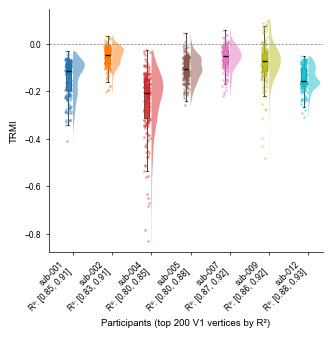

In [11]:
# plot the distribution of surprise ratios for all subjects in one figure
fig, ax = plt.subplots(figsize=cm_to_inch(9, 8))

n_subs = len(subjects)
positions = np.arange(n_subs)
sub_colors = sample_cmap('tab10', n_subs)

for i, (sub, sr) in enumerate(zip(subjects, surprise_ratio_all_subs)):
    valid = sr[~np.isnan(sr)]
    pos = positions[i]

    # Half-violin (right side only)
    parts = ax.violinplot(valid, positions=[pos], showextrema=False, widths=0.6)
    for pc in parts['bodies']:
        m = np.mean(pc.get_paths()[0].vertices[:, 0])
        pc.get_paths()[0].vertices[:, 0] = np.clip(
            pc.get_paths()[0].vertices[:, 0], m, np.inf)
        pc.set_facecolor(sub_colors[i])
        pc.set_edgecolor('none')
        pc.set_alpha(0.5)

    # Box plot (narrow, left side)
    bp = ax.boxplot(valid, positions=[pos - 0.12], widths=0.12,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='k', linewidth=1),
                    whiskerprops=dict(linewidth=0.5),
                    capprops=dict(linewidth=0.5),
                    boxprops=dict(facecolor=sub_colors[i], edgecolor='k',
                                linewidth=0.5, alpha=0.8))

    # Jittered strip plot (left side)
    jitter = np.random.default_rng(42).uniform(-0.08, 0.08, size=len(valid))
    ax.scatter(pos - 0.12 + jitter, valid, s=1.5, color=sub_colors[i],
            alpha=0.25, zorder=2, rasterized=True)

# Build x-tick labels with R² range
xlabels = []
for i, sub in enumerate(subjects):
    rsq = rsq_all_subs[i]
    xlabels.append(f"{sub}\nR²: [{rsq.min():.2f}, {rsq.max():.2f}]")

ax.set_xticks(positions)
ax.set_xticklabels(xlabels, rotation=xticks_rotation, ha='right')
ax.set_ylabel('TRMI')
ax.set_xlabel('Participants (top 200 V1 vertices by R²)')
ax.axhline(0, color='gray', ls='--', lw=0.5)
# ax.set_title('Distribution of TRMI across subjects', fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# fig.tight_layout()
plt.show()
fig.savefig(figure_result_dir / f"group_analysis-pRF_space-fsaverage_desc-prf_viz_grid_simulation_prfampl-0p85.pdf", dpi=600, bbox_inches='tight')
fig.savefig(figure_result_dir / f"group_analysis-pRF_space-fsaverage_desc-prf_viz_grid_simulation_prfampl-0p85.png", dpi=600, bbox_inches='tight')

In [12]:
# print subject-level summary of surprise ratios
for i, sub in enumerate(subjects):
    sr = surprise_ratio_all_subs[i]
    print(f"{sub}: mean surprise ratio = {np.nanmean(sr):.4f}, "
          f"average = {np.nanmean(sr):.4f}, "
          f"valid voxels = {np.sum(~np.isnan(sr))}/{len(sr)}")

sub-001: mean surprise ratio = -0.1433, average = -0.1433, valid voxels = 200/200
sub-002: mean surprise ratio = -0.0538, average = -0.0538, valid voxels = 200/200
sub-004: mean surprise ratio = -0.2427, average = -0.2427, valid voxels = 200/200
sub-005: mean surprise ratio = -0.1055, average = -0.1055, valid voxels = 200/200
sub-007: mean surprise ratio = -0.0583, average = -0.0583, valid voxels = 200/200
sub-009: mean surprise ratio = -0.0771, average = -0.0771, valid voxels = 200/200
sub-012: mean surprise ratio = -0.1442, average = -0.1442, valid voxels = 200/200
